In [1]:
import math
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import wandb
from wandb.apis.public.runs import Run

In [2]:
api = wandb.Api()

In [3]:
# Return (metric, relaxed_metric)
def get_metrics(task: str) -> tuple[str]:
    from eval.vqa import TASKS

    metrics, relaxed_metrics = TASKS[task].METRICS, TASKS[task].RELAXED_METRICS
    assert len(metrics) == 1 and len(relaxed_metrics) == 1
    return (metrics[0], relaxed_metrics[0])


def cleanup_run(run: Run) -> dict[str, Any] | None:
    d = {}
    d["name"] = run.name
    d["size"] = run.config["n_bits"] / (8 * 10**6)
    d["n_steps"] = run.config["training"]["n_steps"]
    fmt = run.config["quantisation"]["fmt"]
    _type = fmt["_type"]
    if _type == "linear":
        d["fmt"] = fmt["element_format"]["_type"]
        if d["fmt"] == "lut":
            name = fmt["element_format"]["name"]
            df = int(name.split("[")[1].split("]")[0])
            d["fmt"] = f"student-t [df={df}]"

    elif _type == "fit_scaled" and fmt["element_family"] == "t":
        d["fmt"] = "student-t [fit]"
    else:
        raise ValueError

    # d["fmt"] = run.config["quantisation"]["fmt"]

    for task in ["vqa", "ai2d", "chartqa", "docvqa"]:
        m, relaxed_m = get_metrics(task)
        d[task] = run.summary[f"downstream.{task}.{m}"]
        d[f"{task}_relaxed"] = run.summary[f"downstream.{task}.{relaxed_m}"]

    history = run.history()
    d["train_loss"] = (
        np.mean(history["train/loss"].tail(10).values)
        if "train/loss" in history
        else None
    )
    d["val_loss"] = run.summary["val/loss"] if "val/loss" in run.summary else None

    return d

In [4]:
runs = api.runs(
    "graphcore/llama-mobile",
    filters={"config.name": "formats-18-03-26", "state": "finished"},
)

In [5]:
df = pd.DataFrame([cleanup_run(run) for run in runs])

In [6]:
df

,name,size,n_steps,fmt,vqa,vqa_relaxed,ai2d,ai2d_relaxed,chartqa,chartqa_relaxed,docvqa,docvqa_relaxed,train_loss,val_loss
0,iconic-cloud-1732,3007.199270,2048,int,0.000977,0.058919,0.000000,0.000000,0.000000,0.010742,0.000000,0.009766,0.672810,1.102691
1,vital-bush-1733,5383.041613,2048,fp,0.745117,0.771159,0.659180,0.688477,0.703125,0.879883,0.805210,0.917969,0.011163,0.012689
2,divine-sunset-1734,3340.530950,2048,student-t [fit],0.609701,0.710286,0.344727,0.352539,0.448242,0.727539,0.381715,0.616211,0.070962,0.107597
3,graceful-glade-1735,5549.707453,2048,fp,0.745768,0.777344,0.666992,0.695312,0.704102,0.882812,0.846705,0.914062,0.010498,0.011901
4,dazzling-butterfly-1736,5883.039133,2048,fp,0.753255,0.777669,0.638672,0.686523,0.741211,0.898438,0.865226,0.907227,0.009835,0.011002
5,elated-lion-1737,4673.857670,2048,int,0.726237,0.779297,0.516602,0.570312,0.630859,0.854492,0.784605,0.845703,0.033713,0.044773
6,azure-tree-1738,4340.525990,2048,int,0.702799,0.755208,0.353516,0.402344,0.594727,0.844727,0.740256,0.835938,0.039898,0.053513
7,fragrant-frog-1739,2840.533430,2048,int,0.000000,0.043945,0.000000,0.000000,0.000000,0.001953,0.000000,0.005859,0.784068,1.260050
8,frosty-cosmos-1740,4173.860150,2048,int,0.691732,0.763021,0.409180,0.443359,0.626953,0.816406,0.678038,0.809570,0.046396,0.063068
9,crisp-snow-1741,4673.857670,2048,student-t [fit],0.756836,0.781576,0.633789,0.668945,0.697266,0.866211,0.809677,0.859375,0.027599,0.035960


In [7]:
# Baseline runs:
# - ethereal-shape-1606: quantised, no training
# - whole-fire-1607: bfloat16

baseline_runs = runs = api.runs(
    "graphcore/llama-mobile",
    filters={"config.name": "baseline-12-02-26", "state": "finished"},
)
baseline = {}
step_0 = {}

for run in runs:
    # Check I'm using the right quantisation for step = 0 baseline
    if run.config["quantisation"] == runs[0].config["quantisation"]:
        assert run.config["training"]["n_steps"] == 0
        for task in ["ai2d", "chartqa", "docvqa", "vqa"]:
            m, relaxed_m = get_metrics(task)
            step_0[task] = (
                run.summary[f"downstream.{task}.{m}"],
                run.summary[f"downstream.{task}.{relaxed_m}"],
            )

    # bfloat16 baseline
    if (
        run.config["quantisation"]["fmt"]["_type"] == "torch"
        and run.config["quantisation"]["fmt"]["dtype"] == "bfloat16"
    ):
        for task in ["ai2d", "chartqa", "docvqa", "vqa"]:
            m, relaxed_m = get_metrics(task)
            baseline[task] = (
                run.summary[f"downstream.{task}.{m}"],
                run.summary[f"downstream.{task}.{relaxed_m}"],
            )

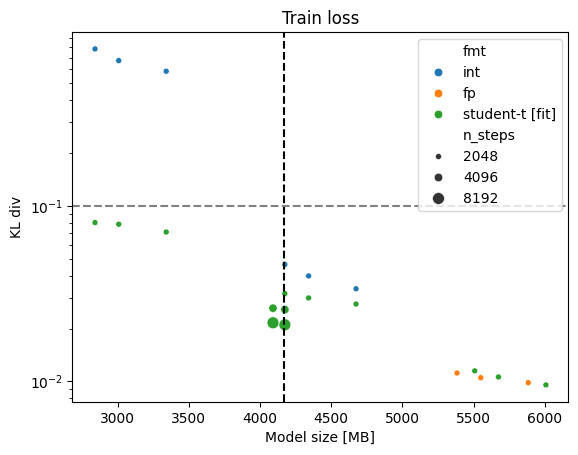

In [8]:
sns.scatterplot(data=df, x="size", y="train_loss", hue="fmt", size="n_steps")
plt.title("Train loss")
plt.xlabel("Model size [MB]")
plt.ylabel("KL div")
plt.yscale("log")
plt.axvline(4170, linestyle="--", color="black")
plt.axhline(0.1, linestyle="--", color="grey")
plt.show()

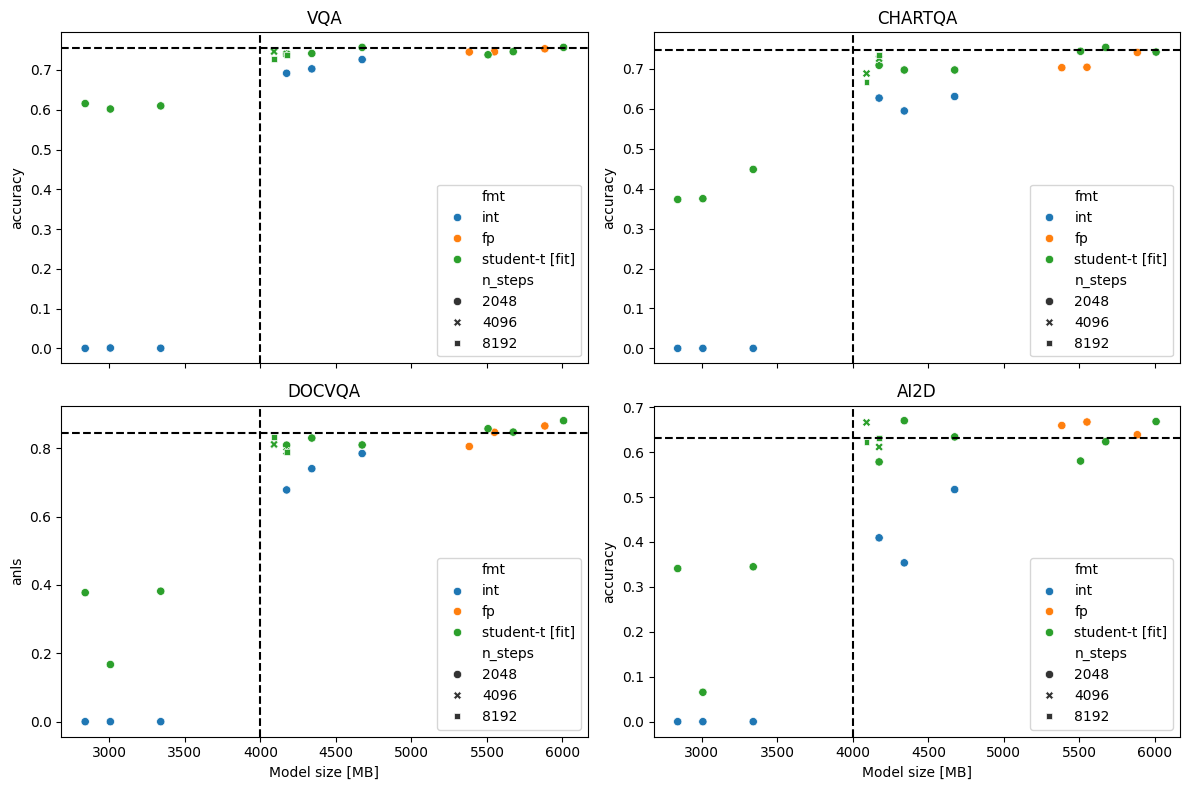

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
axes = axes.flatten()
tasks = ["vqa", "chartqa", "docvqa", "ai2d"]
for ax, task in zip(axes, tasks):
    sns.scatterplot(data=df, x="size", y=task, ax=ax, hue="fmt", style="n_steps")
    
    ax.axhline(baseline[task][0], linestyle="--", color="black")
    ax.axvline(4000, linestyle="--", color="black")
    
    ax.set_title(task.upper())
    ax.set_xlabel("Model size [MB]")
    metrics = get_metrics(task)
    ax.set_ylabel(metrics[0])
    

plt.tight_layout()
plt.show()

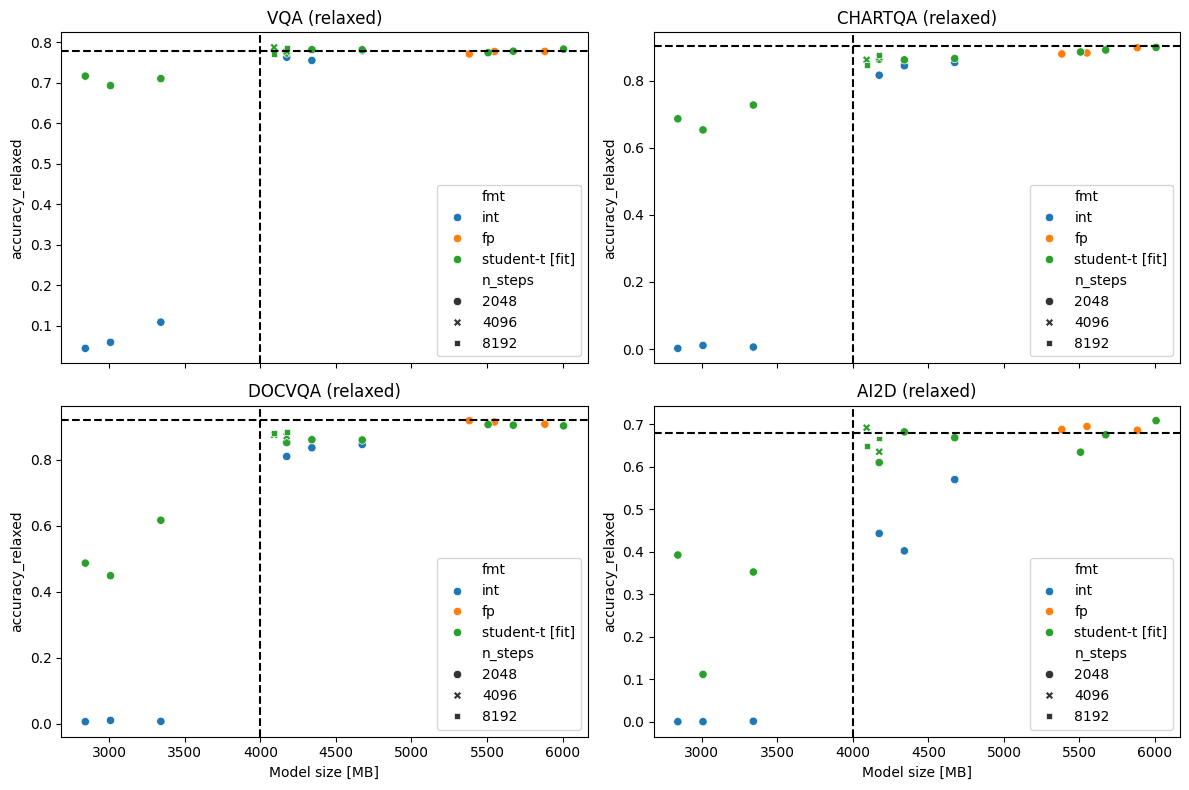

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
axes = axes.flatten()
tasks = ["vqa", "chartqa", "docvqa", "ai2d"]
for ax, task in zip(axes, tasks):
    sns.scatterplot(
        data=df, x="size", y=f"{task}_relaxed", ax=ax, hue="fmt", style="n_steps"
    )

    ax.axhline(baseline[task][1], linestyle="--", color="black")
    ax.axvline(4000, linestyle="--", color="black")

    ax.set_title(f"{task.upper()} (relaxed)")
    ax.set_xlabel("Model size [MB]")
    metrics = get_metrics(task)
    ax.set_ylabel(metrics[1])

plt.tight_layout()
plt.show()